# OCR — locais de interesse + leitura

A carta já chegou recortada (CROPPER, 63×88 mm, P&B). Este notebook:

1. Treina um **YOLOv8 OBB** nas faixas `name` / `number` / `colection` (`OCR/data`).
2. Testa as caixas no split de teste.
3. Recorta cada faixa e lê o texto com **EasyOCR** (modelo pronto — não treinamos OCR do zero).
4. Compara EasyOCR, PaddleOCR e Tesseract com a planilha do split de teste.

`colection` é o nome da classe no Roboflow (typo). Só existe quando a set está **escrita** na carta.

In [38]:
from __future__ import annotations

from pathlib import Path

VERSION = "v1"
EXPERIMENT_NAME = f"ocr-roi-{VERSION}"

ROOT = Path(".").resolve()
if not (ROOT / "train_ocr.ipynb").exists() and (ROOT / "OCR" / "train_ocr.ipynb").exists():
    ROOT = ROOT / "OCR"
REPO = ROOT.parent if ROOT.name == "OCR" else ROOT

DATASET_DIR = ROOT / "data"
DATA_YAML = DATASET_DIR / "data.yaml"
PROJECT_DIR = ROOT / "runs"


def bind_run_paths(run_dir: Path) -> None:
    global RUN_DIR, WEIGHTS_DIR
    RUN_DIR = Path(run_dir)
    WEIGHTS_DIR = RUN_DIR / "weights"


def find_existing_run_dir() -> Path | None:
    names = ("best.pt", f"{EXPERIMENT_NAME}.pt", "last.pt")
    candidates = [
        PROJECT_DIR / EXPERIMENT_NAME,
        PROJECT_DIR / "obb" / EXPERIMENT_NAME,
    ]
    for folder in candidates:
        weights = folder / "weights"
        if any((weights / name).exists() for name in names):
            return folder
    if PROJECT_DIR.exists():
        for name in names:
            for pt in PROJECT_DIR.rglob(name):
                if EXPERIMENT_NAME in pt.parts and pt.parent.name == "weights":
                    return pt.parent.parent
    return None


bind_run_paths(PROJECT_DIR / EXPERIMENT_NAME)
_existing = find_existing_run_dir()
if _existing:
    bind_run_paths(_existing)

PRETRAINED_MODEL = "yolov8n-obb.pt"
EPOCHS = 80
IMGSZ = 800
BATCH = 16
PATIENCE = 20
SEED = 42
WORKERS = 0
CONF = 0.4
MAX_SHOW = 8

LOSS = dict(box=7.5, dfl=1.5, angle=1.0)
AUGMENT = dict(
    degrees=8.0,
    flipud=0.0,
    fliplr=0.0,
    translate=0.04,
    scale=0.2,
    shear=0.0,
    hsv_h=0.0,
    hsv_s=0.2,
    hsv_v=0.2,
    mosaic=0.2,
    mixup=0.0,
    erasing=0.0,
    close_mosaic=10,
    cos_lr=True,
)

print(f"Experimento : {EXPERIMENT_NAME}")
print(f"Dataset     : {DATASET_DIR}  yaml={DATA_YAML.exists()}")
print(f"Saída       : {RUN_DIR}")
print(f"Modelo      : {PRETRAINED_MODEL} | epochs={EPOCHS} | imgsz={IMGSZ} | batch={BATCH}")


Experimento : ocr-roi-v1
Dataset     : C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\OCR\data  yaml=True
Saída       : C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\OCR\runs\ocr-roi-v1
Modelo      : yolov8n-obb.pt | epochs=80 | imgsz=800 | batch=16


## 1. Ambiente

In [39]:
import subprocess
import sys

REQUIRED = {
    "ultralytics": "ultralytics",
    "pandas": "pandas",
    "pyyaml": "yaml",
    "matplotlib": "matplotlib",
    "opencv-python": "cv2",
    "pillow": "PIL",
}
missing = []
for pip_name, module_name in REQUIRED.items():
    try:
        __import__(module_name)
    except ImportError:
        missing.append(pip_name)
if missing:
    print(f"Instalando: {missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("Dependências de treino ok.")

try:
    import easyocr  # noqa: F401
    print("EasyOCR ok.")
except ImportError:
    print("Instalando easyocr...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "easyocr"])


Dependências de treino ok.
EasyOCR ok.


In [40]:
from datetime import datetime
import platform

import pandas as pd
import torch
import ultralytics

print(pd.DataFrame([
    {"Item": "Data/hora", "Valor": datetime.now().strftime("%Y-%m-%d %H:%M:%S")},
    {"Item": "SO", "Valor": platform.platform()},
    {"Item": "Python", "Valor": platform.python_version()},
    {"Item": "PyTorch", "Valor": torch.__version__},
    {"Item": "Ultralytics", "Valor": ultralytics.__version__},
    {"Item": "CUDA", "Valor": torch.cuda.is_available()},
    {"Item": "GPU", "Valor": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "—"},
]).to_string(index=False))


       Item                     Valor
  Data/hora       2026-09-26 13:12:02
         SO Windows-11-10.0.26200-SP0
     Python                    3.14.7
    PyTorch              2.11.0+cu128
Ultralytics                   8.4.129
       CUDA                      True
        GPU   NVIDIA GeForce RTX 5060


## 2. Dataset (Roboflow em `OCR/data`)

In [41]:
import yaml
from collections import Counter

if not DATA_YAML.exists():
    raise FileNotFoundError(
        f"Exporte o YOLO OBB do Roboflow para {DATASET_DIR} (falta data.yaml)."
    )

cfg = yaml.safe_load(DATA_YAML.read_text(encoding="utf-8"))
names = cfg.get("names") or {}
if isinstance(names, list):
    names = dict(enumerate(names))
print("classes:", names)

rows = []
cls_total = Counter()
for split in ("train", "valid", "test"):
    img_dir = DATASET_DIR / split / "images"
    lab_dir = DATASET_DIR / split / "labels"
    images = sorted(p for p in img_dir.glob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"})
    labels = list(lab_dir.glob("*.txt")) if lab_dir.exists() else []
    counts = Counter()
    empty = 0
    for lp in labels:
        text = lp.read_text(encoding="utf-8").strip()
        if not text:
            empty += 1
            continue
        for line in text.splitlines():
            cid = int(line.split()[0])
            counts[cid] += 1
            cls_total[cid] += 1
    rows.append({
        "split": split,
        "imagens": len(images),
        "labels": len(labels),
        "vazios": empty,
        **{names.get(i, str(i)): counts[i] for i in sorted(names)},
    })
print(pd.DataFrame(rows).to_string(index=False))
print("total por classe:", {names.get(k, k): v for k, v in sorted(cls_total.items())})


classes: {0: 'colection', 1: 'name', 2: 'number'}
split  imagens  labels  vazios  colection  name  number
train      205     205       0        137   205     205
valid       59      59       0         33    58      58
 test       29      29       0         20    29      29
total por classe: {'colection': 190, 'name': 292, 'number': 292}


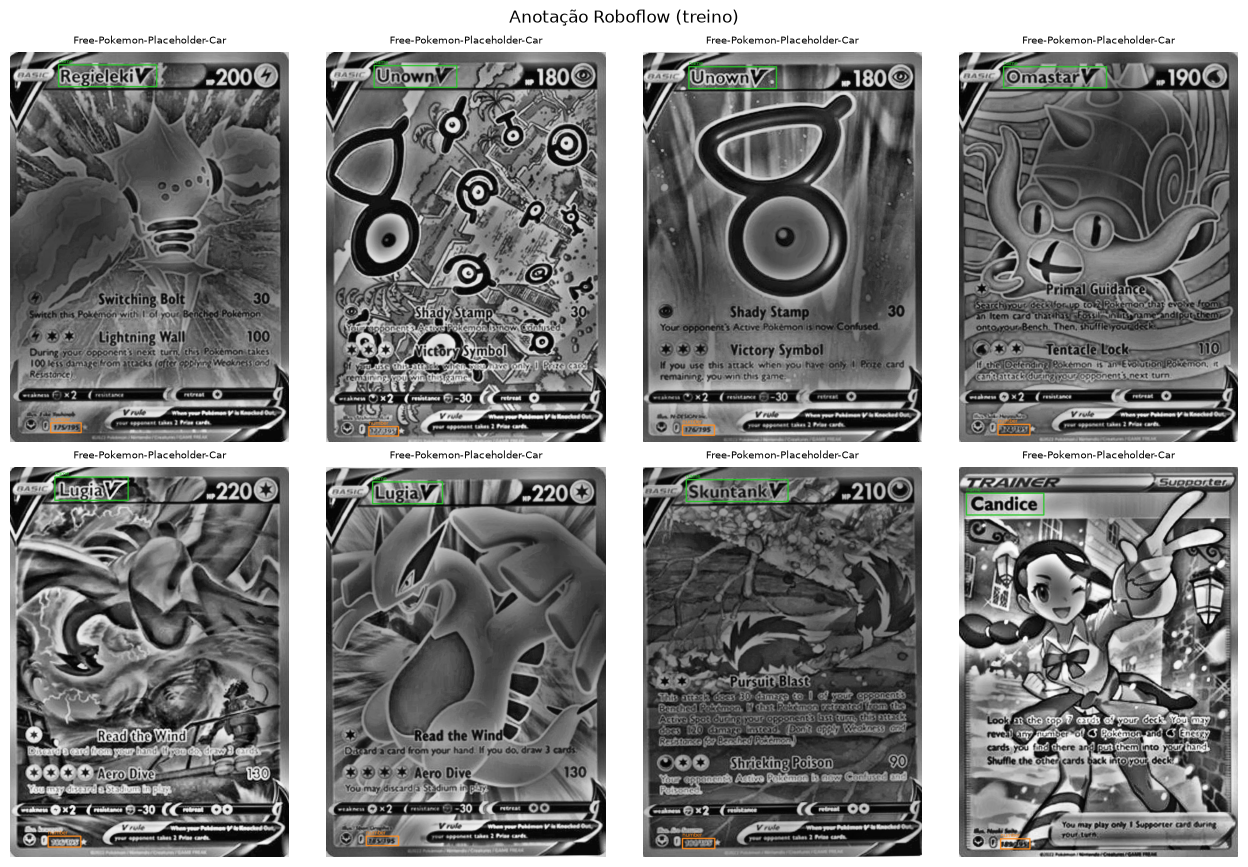

In [42]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

COLORS = {0: (40, 180, 255), 1: (40, 200, 40), 2: (30, 140, 255)}


def draw_obb_label(bgr: np.ndarray, label_path: Path, names: dict) -> np.ndarray:
    vis = bgr.copy()
    h, w = vis.shape[:2]
    text = label_path.read_text(encoding="utf-8").strip()
    if not text:
        return vis
    for line in text.splitlines():
        parts = line.split()
        cid = int(parts[0])
        coords = np.array([float(x) for x in parts[1:]], dtype=np.float32)
        if coords.size == 8:
            pts = coords.reshape(4, 2)
            pts[:, 0] *= w
            pts[:, 1] *= h
        else:
            cx, cy, bw, bh = coords[:4]
            x0, y0 = (cx - bw / 2) * w, (cy - bh / 2) * h
            x1, y1 = (cx + bw / 2) * w, (cy + bh / 2) * h
            pts = np.array([[x0, y0], [x1, y0], [x1, y1], [x0, y1]], dtype=np.float32)
        color = COLORS.get(cid, (200, 200, 200))
        cv2.polylines(vis, [pts.astype(np.int32)], True, color, 2, cv2.LINE_AA)
        x, y = int(pts[:, 0].min()), int(pts[:, 1].min())
        cv2.putText(vis, names.get(cid, str(cid)), (x, max(14, y - 4)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1, cv2.LINE_AA)
    return vis


train_imgs = sorted((DATASET_DIR / "train" / "images").glob("*.jpg"))[:MAX_SHOW]
cols = min(4, max(1, len(train_imgs)))
rows_n = int(np.ceil(len(train_imgs) / cols))
fig, axes = plt.subplots(rows_n, cols, figsize=(3.2 * cols, 4.4 * rows_n))
axes = np.atleast_1d(axes).ravel()
for ax, img_path in zip(axes, train_imgs):
    bgr = cv2.imread(str(img_path))
    lab = DATASET_DIR / "train" / "labels" / (img_path.stem + ".txt")
    vis = draw_obb_label(bgr, lab, names) if lab.exists() else bgr
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(img_path.name[:28], fontsize=7)
    ax.axis("off")
for ax in axes[len(train_imgs):]:
    ax.axis("off")
fig.suptitle("Anotação Roboflow (treino)")
plt.tight_layout()
plt.show()


## 3. Treinar YOLO OBB (locais de interesse)

Altere `VERSION` e rode. Se já existir `ocr-roi-v1.pt`, a célula seguinte só carrega.

In [43]:
from ultralytics import YOLO

final_pt = WEIGHTS_DIR / f"{EXPERIMENT_NAME}.pt"
best_pt = WEIGHTS_DIR / "best.pt"
if final_pt.exists() or best_pt.exists():
    print(f"Já treinado: {final_pt if final_pt.exists() else best_pt}")
    print("Apague a pasta do run se quiser retreinar.")
else:
    model = YOLO(PRETRAINED_MODEL)
    results = model.train(
        data=str(DATA_YAML.resolve()),
        epochs=EPOCHS,
        imgsz=IMGSZ,
        batch=BATCH,
        patience=PATIENCE,
        seed=SEED,
        workers=WORKERS,
        project=str(PROJECT_DIR),
        name=EXPERIMENT_NAME,
        exist_ok=True,
        device=0 if torch.cuda.is_available() else "cpu",
        **LOSS,
        **AUGMENT,
    )
    bind_run_paths(Path(results.save_dir))
    print(f"Treino em {RUN_DIR}")


Já treinado: C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\OCR\runs\ocr-roi-v1\weights\ocr-roi-v1.pt
Apague a pasta do run se quiser retreinar.


## 4. Validar e copiar pesos

In [44]:
from shutil import copy2

_existing = find_existing_run_dir()
if _existing:
    bind_run_paths(_existing)

best_pt = WEIGHTS_DIR / "best.pt"
named_pt = WEIGHTS_DIR / f"{EXPERIMENT_NAME}.pt"
if best_pt.exists() and not named_pt.exists():
    copy2(best_pt, named_pt)
WEIGHTS = named_pt if named_pt.exists() else best_pt
if not WEIGHTS.exists():
    raise FileNotFoundError(f"Treine antes. Faltando: {WEIGHTS_DIR}")

roi_model = YOLO(str(WEIGHTS))
val = roi_model.val(
    data=str(DATA_YAML.resolve()),
    split="val",
    imgsz=IMGSZ,
    batch=BATCH,
    workers=WORKERS,
    device=0 if torch.cuda.is_available() else "cpu",
    plots=True,
)
print(f"Pesos : {WEIGHTS}")
metrics = getattr(val, "obb", None) or getattr(val, "box", None)
if metrics is not None:
    print(f"mAP50 : {float(metrics.map50):.3f}   mAP50-95: {float(metrics.map):.3f}")
else:
    print(getattr(val, "results_dict", val))


Ultralytics 8.4.129  Python-3.14.7 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060, 8150MiB)
YOLOv8n-obb summary (fused): 82 layers, 3,077,804 parameters, 0 gradients, 8.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 346.8131.4 MB/s, size: 148.3 KB)
val: Scanning C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\OCR\data\valid\labels.cache... 59 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 59/59 27.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.5it/s 1.6s0.6s
                   all         59        149      0.979      0.989      0.977      0.807
             colection         32         33       0.98       0.97      0.965      0.818
                  name         58         58      0.975          1       0.98      0.816
                number         58         58      0.983      0.997      0.985      0.786
Speed: 1.1ms preprocess, 2.6ms inference, 0.0ms loss, 4.1ms postprocess 

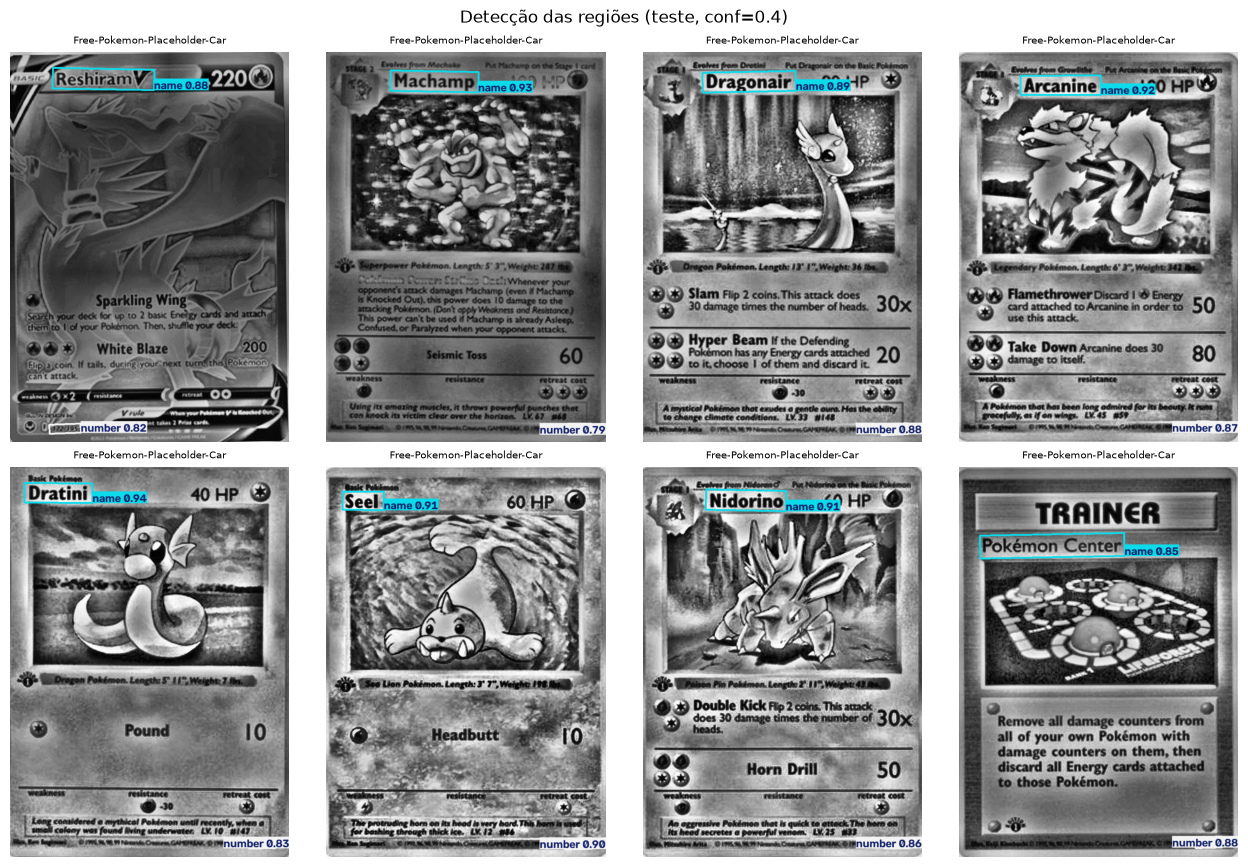

In [45]:
test_dir = DATASET_DIR / "test" / "images"
test_imgs = sorted(p for p in test_dir.glob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"})
show = test_imgs[:MAX_SHOW]
if not show:
    raise FileNotFoundError(test_dir)

preds = roi_model.predict(
    source=[str(p) for p in show],
    conf=CONF,
    imgsz=IMGSZ,
    device=0 if torch.cuda.is_available() else "cpu",
    verbose=False,
)

cols = min(4, len(show))
rows_n = int(np.ceil(len(show) / cols))
fig, axes = plt.subplots(rows_n, cols, figsize=(3.2 * cols, 4.4 * rows_n))
axes = np.atleast_1d(axes).ravel()
for ax, result in zip(axes, preds):
    vis = result.plot()
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(Path(result.path).name[:28], fontsize=7)
    ax.axis("off")
for ax in axes[len(show):]:
    ax.axis("off")
fig.suptitle(f"Detecção das regiões (teste, conf={CONF})")
plt.tight_layout()
plt.show()


## 5. OCR nas faixas detectadas

EasyOCR lê **só** `name`, `number` e `collection` (esta última só se o detector achar caixa).

In [46]:
import sys

sys.path.insert(0, str(ROOT))
from read_card import read_card

import easyocr

reader = easyocr.Reader(["en", "pt"], gpu=torch.cuda.is_available())
print("EasyOCR carregado.")


EasyOCR carregado.


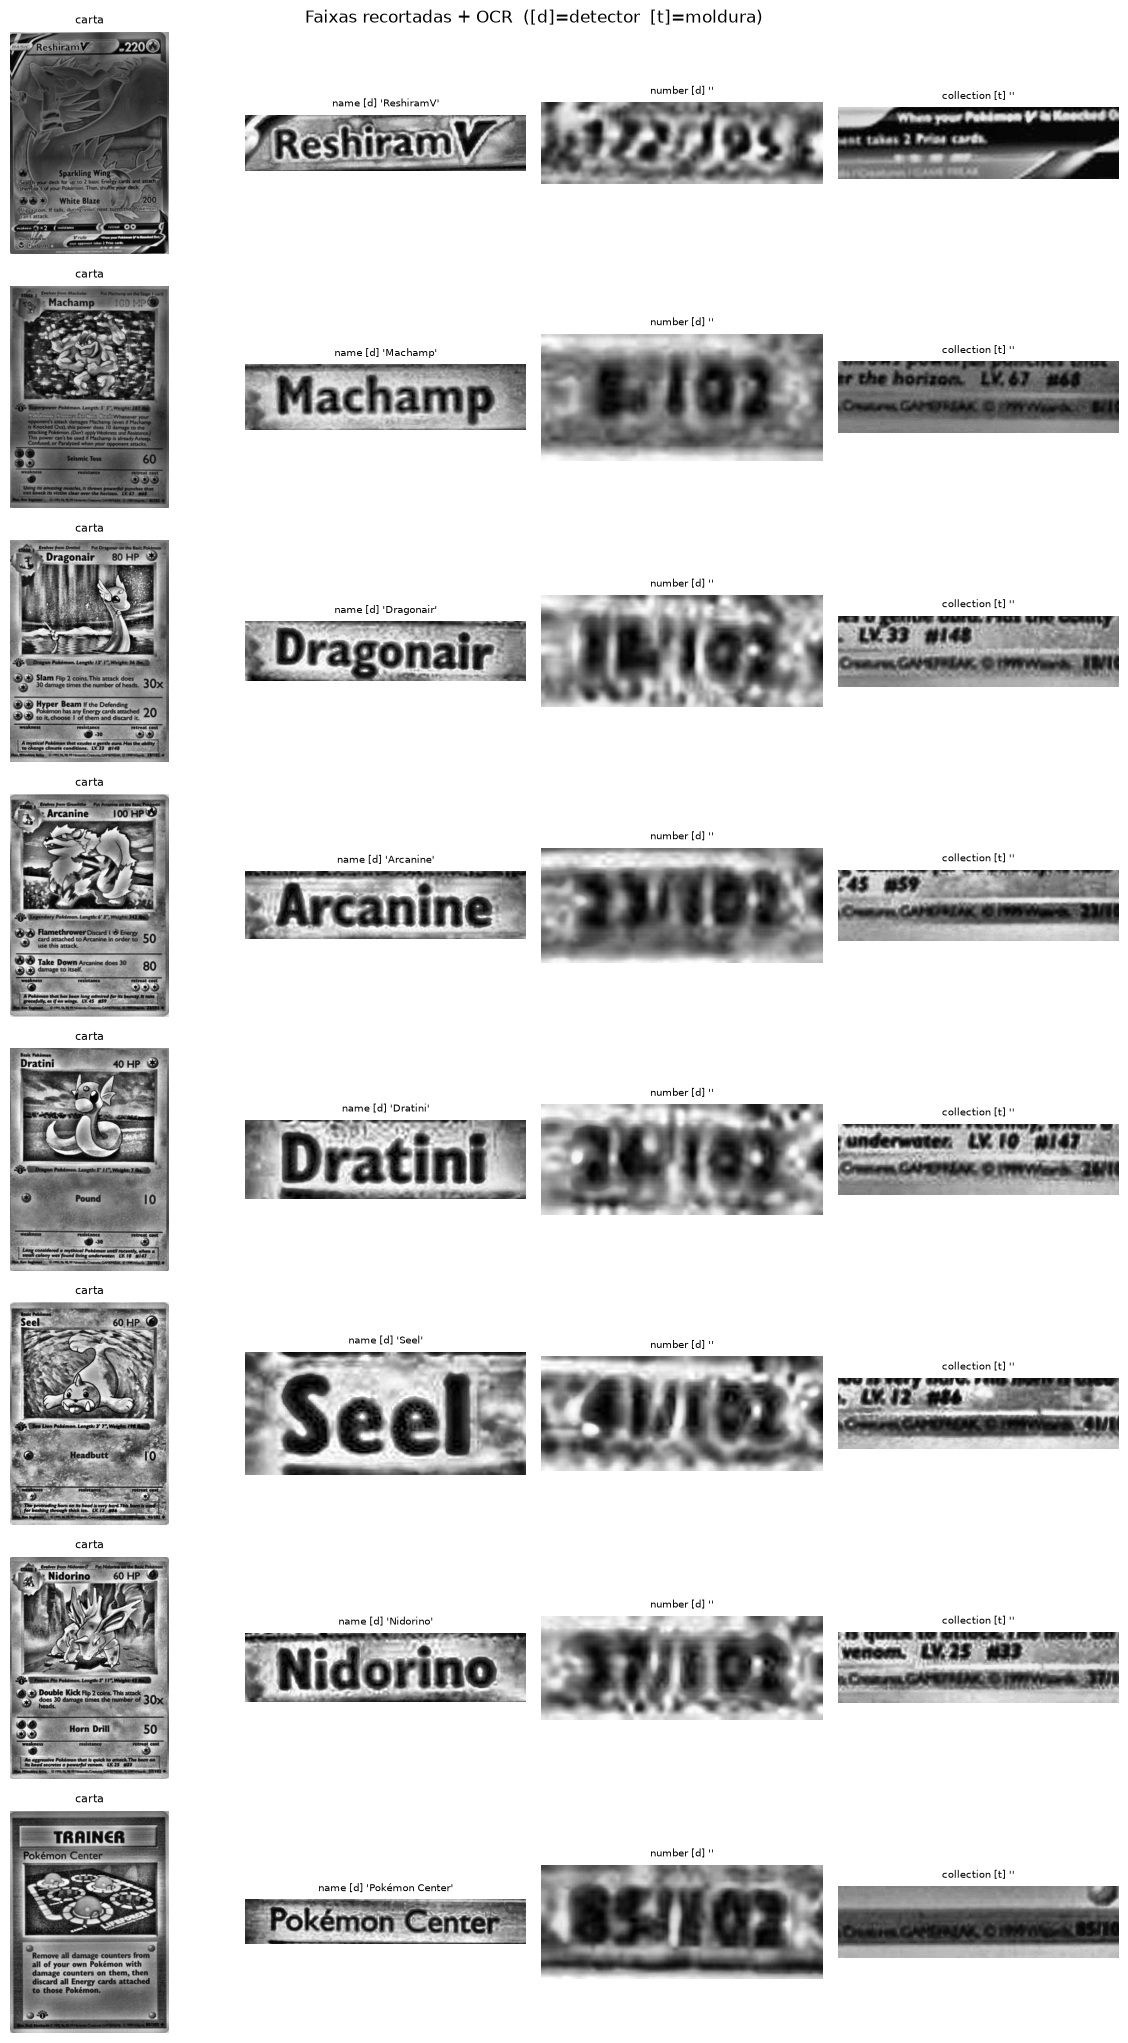

                                 arquivo           name number collection
Free-Pokemon-Placeholder-Card-Generator-      ReshiramV                  
Free-Pokemon-Placeholder-Card-Generator-        Machamp                  
Free-Pokemon-Placeholder-Card-Generator-      Dragonair                  
Free-Pokemon-Placeholder-Card-Generator-       Arcanine                  
Free-Pokemon-Placeholder-Card-Generator-        Dratini                  
Free-Pokemon-Placeholder-Card-Generator-           Seel                  
Free-Pokemon-Placeholder-Card-Generator-       Nidorino                  
Free-Pokemon-Placeholder-Card-Generator- Pokémon Center                  


In [47]:
ocr_rows = []
n_show = min(MAX_SHOW, len(preds))
fig, axes = plt.subplots(n_show, 4, figsize=(12, 2.6 * n_show))
if n_show == 1:
    axes = np.array([axes])

for i, result in enumerate(preds[:n_show]):
    card = read_card(result, reader, conf_min=CONF)
    ocr_rows.append({
        "arquivo": Path(result.path).name[:40],
        "name": card.name,
        "number": card.number,
        "collection": card.collection,
    })
    full = result.orig_img
    axes[i, 0].imshow(cv2.cvtColor(full, cv2.COLOR_BGR2RGB) if full.ndim == 3 else full, cmap="gray")
    axes[i, 0].set_title("carta", fontsize=8)
    for j, field in enumerate(("name", "number", "collection"), start=1):
        region = card.regions[field]
        img = region.image
        if img.ndim == 3:
            axes[i, j].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        else:
            axes[i, j].imshow(img, cmap="gray")
        tag = region.source[0]
        axes[i, j].set_title(f"{field} [{tag}] {region.text[:18]!r}", fontsize=7)
    for ax in axes[i]:
        ax.axis("off")

fig.suptitle("Faixas recortadas + OCR  ([d]=detector  [t]=moldura)")
plt.tight_layout()
plt.show()
print(pd.DataFrame(ocr_rows).to_string(index=False))


## 6. Teste no split inteiro (tabela)

In [48]:
all_preds = roi_model.predict(
    source=str(test_dir),
    conf=CONF,
    imgsz=IMGSZ,
    device=0 if torch.cuda.is_available() else "cpu",
    verbose=False,
)
table = []
for result in all_preds:
    card = read_card(result, reader, conf_min=CONF)
    table.append({
        "arquivo": Path(result.path).stem[:48],
        "name": card.name,
        "number": card.number,
        "collection": card.collection,
        "name_src": card.regions["name"].source,
        "number_src": card.regions["number"].source,
        "collection_src": card.regions["collection"].source,
    })
df = pd.DataFrame(table)
out_csv = ROOT / "runs" / f"{EXPERIMENT_NAME}_ocr_test.csv"
out_csv.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(out_csv, index=False, encoding="utf-8")
print(df.to_string(index=False))
print(f"\nCSV: {out_csv}")


                                         arquivo                name  number collection name_src number_src collection_src
Free-Pokemon-Placeholder-Card-Generator-_-TCG-Bi           ReshiramV                         det        det       template
Free-Pokemon-Placeholder-Card-Generator-_-TCG-Bi             Machamp                         det        det       template
Free-Pokemon-Placeholder-Card-Generator-_-TCG-Bi           Dragonair                         det        det       template
Free-Pokemon-Placeholder-Card-Generator-_-TCG-Bi            Arcanine                         det        det       template
Free-Pokemon-Placeholder-Card-Generator-_-TCG-Bi             Dratini                         det        det       template
Free-Pokemon-Placeholder-Card-Generator-_-TCG-Bi                Seel                         det        det       template
Free-Pokemon-Placeholder-Card-Generator-_-TCG-Bi            Nidorino                         det        det       template
Free-Pokemon-Pla

## 7. Três OCRs contra a planilha do teste

A planilha `data/cards_read.csv` (a mesma `cards_read - Sheet1.csv`) tem a leitura correta das **29** cartas do split de teste. A célula abaixo recorta as faixas com o YOLO e lê cada uma com EasyOCR, PaddleOCR e Tesseract.

Um campo conta como acerto quando o texto normalizado fica igual ao da planilha:

- **nome:** maiúscula, acento e espaço extra não mudam o acerto
- **número:** zero à esquerda não muda (`8/102` = `008/102`); prefixo de letras permanece (`GG34/GG70`); número sem barra, como `13`, aceita `013`
- **coleção:** as 3 primeiras letras, sem diferenciar maiúscula de minúscula, e pode errar uma letra (`JTGpt` = `jtg` = `JIG`); célula vazia exige leitura vazia

A carta só conta como acerto se nome, número e coleção acertam juntos. A comparação usa o texto que cada modelo devolveu, antes da limpeza que transforma tudo em `NNN/NNN` só com dígitos — senão `GG34/GG70` e `13` seriam erro dos três ao mesmo tempo.

In [49]:
import re
import shutil
import unicodedata

import cv2
import numpy as np
import pandas as pd

import importlib

import read_card as read_card_mod

importlib.reload(read_card_mod)
from read_card import (
    _FIELD_ALLOW,
    _NUMBER_TRANSLATE,
    _parse_ocr_items,
    _readtext,
    _strip_variants,
    enhance_strip,
    fill_missing,
    regions_from_obb,
)

sheet_candidates = [
    DATASET_DIR / "cards_read - Sheet1.csv",
    DATASET_DIR / "cards_read.csv",
]
sheet_path = next((path for path in sheet_candidates if path.exists()), None)
if sheet_path is None:
    raise FileNotFoundError("Planilha do teste não encontrada em OCR/data.")

gt = pd.read_csv(sheet_path, encoding="utf-8-sig", dtype=str).fillna("")
gt.columns = [col.strip() for col in gt.columns]
for col in ("Imagem", "Nome", "Numero", "Colecao"):
    gt[col] = gt[col].astype(str).str.strip()

test_dir = DATASET_DIR / "test" / "images"
missing_imgs = [name for name in gt["Imagem"] if not (test_dir / name).is_file()]
if missing_imgs:
    raise FileNotFoundError(f"{len(missing_imgs)} imagens da planilha não estão em test/: {missing_imgs[:3]}")

OCR_CONF = 0.25
ENGINES = ("easyocr", "paddleocr", "tesseract")
LABEL = {"easyocr": "EasyOCR", "paddleocr": "PaddleOCR", "tesseract": "Tesseract"}


def fold_name(text: str) -> str:
    text = unicodedata.normalize("NFKD", text or "")
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = re.sub(r"[^0-9A-Za-z]+", " ", text).casefold()
    return re.sub(r"\s+", " ", text).strip()


def fold_collection(text: str) -> str:
    """3 primeiras letras, sem diferenciar maiúscula de minúscula."""
    code = re.sub(r"[^A-Za-z0-9]+", "", text or "").upper()
    return code[:3]


def fold_number(text: str) -> str:
    """Iguala zero à esquerda e preserva prefixo de letras (GG, SWSH)."""
    raw = (text or "").upper().replace(" ", "").replace("\\", "/").replace("⁄", "/")
    prefixed = re.search(r"([A-Z]{2,})(\d{1,4})/([A-Z]{2,})(\d{1,4})", raw)
    if prefixed:
        left, a, right, b = prefixed.groups()
        return f"{left}{int(a)}/{right}{int(b)}"
    translated = raw.translate(_NUMBER_TRANSLATE)
    plain = re.search(r"(\d{1,4})/(\d{1,4})", translated)
    if plain:
        return f"{int(plain.group(1))}/{int(plain.group(2))}"
    if "/" not in translated:
        digits = re.sub(r"\D", "", translated)
        letters = re.sub(r"[^A-Z]", "", translated)
        if digits and not letters:
            return str(int(digits))
    return re.sub(r"[^A-Z0-9/]", "", translated)


def edit_distance(left: str, right: str) -> int:
    if left == right:
        return 0
    if not left:
        return len(right)
    if not right:
        return len(left)
    prev = list(range(len(right) + 1))
    for i, ca in enumerate(left, start=1):
        curr = [i]
        for j, cb in enumerate(right, start=1):
            curr.append(min(prev[j] + 1, curr[j - 1] + 1, prev[j - 1] + (ca != cb)))
        prev = curr
    return prev[-1]


def same_collection(expected: str, predicted: str) -> bool:
    """Acerto: 3 primeiras letras, podendo errar uma, sem diferenciar maiúscula."""
    left = fold_collection(expected)
    right = fold_collection(predicted)
    if not left and not right:
        return True
    if not left or not right:
        return False
    return edit_distance(left, right) <= 1


def same_field(field: str, expected: str, predicted: str) -> bool:
    if field == "name":
        return fold_name(expected) == fold_name(predicted)
    if field == "number":
        return fold_number(expected) == fold_number(predicted)
    return same_collection(expected, predicted)


def _easy_text(image: np.ndarray, field: str) -> str:
    min_h = 80 if field == "collection" else 112
    enhanced = enhance_strip(image, min_h=min_h)
    allow = _FIELD_ALLOW[field]

    def _run(view: np.ndarray) -> tuple[str, float]:
        rgb = cv2.cvtColor(view, cv2.COLOR_GRAY2RGB)
        return _parse_ocr_items(_readtext(reader, rgb, allow))

    text, conf = _run(enhanced)
    if text.strip():
        return text
    if field == "name":
        text, _conf = _run(255 - enhanced)
        return text
    if field == "number":
        best_text, best_conf = "", -1.0
        for view in _strip_variants(enhanced)[1:]:
            cand, cand_conf = _run(view)
            if cand.strip() and cand_conf > best_conf:
                best_text, best_conf = cand, cand_conf
        return best_text
    return text


def _paddle_text(image: np.ndarray, field: str) -> str:
    min_h = 80 if field == "collection" else 112
    gray = enhance_strip(image, min_h=min_h)
    view = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR) if gray.ndim == 2 else gray
    result = paddle(view, use_det=False, use_cls=False)
    texts = [str(item).strip() for item in (getattr(result, "txts", None) or []) if str(item).strip()]
    return " ".join(texts)


def _tesseract_text(image: np.ndarray, field: str) -> str:
    import pytesseract

    pytesseract.pytesseract.tesseract_cmd = str(tesseract_cmd)
    view = enhance_strip(image, min_h=80 if field == "collection" else 112)
    config = "--psm 7"
    if field == "number":
        config += " -c tessedit_char_whitelist=0123456789/OoQqDdIiLlZzSsGgBb"
    elif field == "collection":
        config += " -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789"
    data = pytesseract.image_to_data(view, lang="eng", config=config, output_type=pytesseract.Output.DICT)
    words = [str(word).strip() for word in data.get("text", []) if str(word).strip()]
    return " ".join(words)


if "reader" not in globals():
    import easyocr

    reader = easyocr.Reader(["en", "pt"], gpu=torch.cuda.is_available())

from rapidocr import RapidOCR

paddle = RapidOCR(params={"Global.log_level": "error"})
tesseract_cmd = shutil.which("tesseract")
if not tesseract_cmd:
    for candidate in (
        Path(r"C:\Program Files\Tesseract-OCR\tesseract.exe"),
        Path(r"C:\Program Files (x86)\Tesseract-OCR\tesseract.exe"),
    ):
        if candidate.is_file():
            tesseract_cmd = str(candidate)
            break
if not tesseract_cmd:
    raise FileNotFoundError("Tesseract não encontrado.")

paths = [str(test_dir / name) for name in gt["Imagem"]]
print(f"Planilha: {sheet_path.name}  |  cartas: {len(paths)}  |  conf das faixas: {OCR_CONF}")
preds = roi_model.predict(
    source=paths,
    conf=OCR_CONF,
    imgsz=IMGSZ,
    device=0 if torch.cuda.is_available() else "cpu",
    verbose=False,
)

by_name = {Path(result.path).name: result for result in preds}
if set(by_name) != set(gt["Imagem"]):
    raise RuntimeError("A predição não devolveu todas as imagens da planilha.")

rows = []
for index, expected in enumerate(gt.itertuples(index=False), start=1):
    print(f"[{index}/{len(gt)}] {expected.Imagem.split('_jpg')[0][:48]}", flush=True)
    result = by_name[expected.Imagem]
    regions = fill_missing(result.orig_img, regions_from_obb(result, result.orig_img, conf_min=OCR_CONF))
    read = {}
    origin = {}
    for field, column in (("name", "Nome"), ("number", "Numero"), ("collection", "Colecao")):
        region = regions[field]
        origin[field] = region.source
        skip = field == "collection" and region.source != "det"
        texts = {"easyocr": "", "paddleocr": "", "tesseract": ""}
        if not skip and region.image is not None and region.image.size:
            texts["easyocr"] = _easy_text(region.image, field)
            texts["paddleocr"] = _paddle_text(region.image, field)
            texts["tesseract"] = _tesseract_text(region.image, field)
        truth = getattr(expected, column)
        read[field] = texts
        rows.append({
            "imagem": expected.Imagem,
            "campo": field,
            "origem": origin[field],
            "certo": truth,
            "easyocr": texts["easyocr"],
            "paddleocr": texts["paddleocr"],
            "tesseract": texts["tesseract"],
            "ok_easyocr": same_field(field, truth, texts["easyocr"]),
            "ok_paddleocr": same_field(field, truth, texts["paddleocr"]),
            "ok_tesseract": same_field(field, truth, texts["tesseract"]),
        })

detail = pd.DataFrame(rows)
out_csv = ROOT / "runs" / f"{EXPERIMENT_NAME}_vs_planilha.csv"
out_csv.parent.mkdir(parents=True, exist_ok=True)
detail.to_csv(out_csv, index=False, encoding="utf-8")

n_cards = detail["imagem"].nunique()
summary = []
for engine in ENGINES:
    ok_col = f"ok_{engine}"
    by_field = {field: int(detail.loc[detail["campo"] == field, ok_col].sum()) for field in ("name", "number", "collection")}
    card_ok = int(detail.groupby("imagem")[ok_col].all().sum())
    summary.append({
        "modelo": LABEL[engine],
        "nome": f"{by_field['name']}/{n_cards}",
        "numero": f"{by_field['number']}/{n_cards}",
        "colecao": f"{by_field['collection']}/{n_cards}",
        "carta": f"{card_ok}/{n_cards}",
        "carta_%": round(100 * card_ok / n_cards, 1),
    })
summary_df = pd.DataFrame(summary).sort_values("carta_%", ascending=False)
print("\nAcerto no teste (planilha):")
print(summary_df.to_string(index=False))

col_boxes = detail[(detail["campo"] == "collection") & (detail["origem"] == "det")]
if len(col_boxes):
    bits = [
        f"{LABEL[engine]} {int(col_boxes[f'ok_{engine}'].sum())}/{len(col_boxes)}"
        for engine in ENGINES
    ]
    print("\nColeção só onde o detector achou a faixa:", " | ".join(bits))

misses = detail[~(detail["ok_easyocr"] & detail["ok_paddleocr"] & detail["ok_tesseract"])].copy()
if misses.empty:
    print("\nNenhum campo divergiu da planilha.")
else:
    show = misses.assign(arquivo=misses["imagem"].str.split("_jpg").str[0].str.slice(0, 42))
    print("\nCampos em que pelo menos um modelo errou:")
    print(show[["arquivo", "campo", "origem", "certo", "easyocr", "paddleocr", "tesseract"]].to_string(index=False))
print(f"\nCSV: {out_csv}")


Planilha: cards_read.csv  |  cartas: 29  |  conf das faixas: 0.25
[1/29] Free-Pokemon-Placeholder-Card-Generator-_-TCG-Bi
[2/29] Free-Pokemon-Placeholder-Card-Generator-_-TCG-Bi
[3/29] Free-Pokemon-Placeholder-Card-Generator-_-TCG-Bi
[4/29] Free-Pokemon-Placeholder-Card-Generator-_-TCG-Bi
[5/29] Free-Pokemon-Placeholder-Card-Generator-_-TCG-Bi
[6/29] Free-Pokemon-Placeholder-Card-Generator-_-TCG-Bi
[7/29] Free-Pokemon-Placeholder-Card-Generator-_-TCG-Bi
[8/29] Free-Pokemon-Placeholder-Card-Generator-_-TCG-Bi
[9/29] IMG_6677_card_04_0-96_bw
[10/29] IMG_6677_card_05_0-96_bw
[11/29] IMG_6679_card_03_0-97_bw
[12/29] IMG_6681_card_01_0-97_bw
[13/29] IMG_6681_card_07_0-96_bw
[14/29] IMG_6682_card_00_0-97_bw
[15/29] IMG_6682_card_06_0-97_bw
[16/29] IMG_6683_card_04_0-97_bw
[17/29] IMG_6686_card_08_0-96_bw
[18/29] IMG_6687_card_05_0-97_bw
[19/29] IMG_6688_card_04_0-97_bw
[20/29] IMG_6689_card_07_0-96_bw
[21/29] IMG_6692_card_05_0-97_bw
[22/29] IMG_6697_card_02_0-97_bw
[23/29] IMG_6702_card_02_

## 8. Gráficos da comparação

Acertos e erros de cada OCR em nome, número e coleção. Verde é acerto. Amarelo é erro razoável: errou, mas a leitura ficou pelo menos 80% parecida com a planilha. Vermelho é erro brusco: veio vazio quando havia texto, veio texto quando a planilha estava vazia, ou a leitura ficou bem diferente. Na coleção, o acerto são as 3 primeiras letras, sem diferenciar maiúscula de minúscula, e uma letra errada ainda conta. No fim, a lista mostra as cartas em que o melhor modelo mais errou.

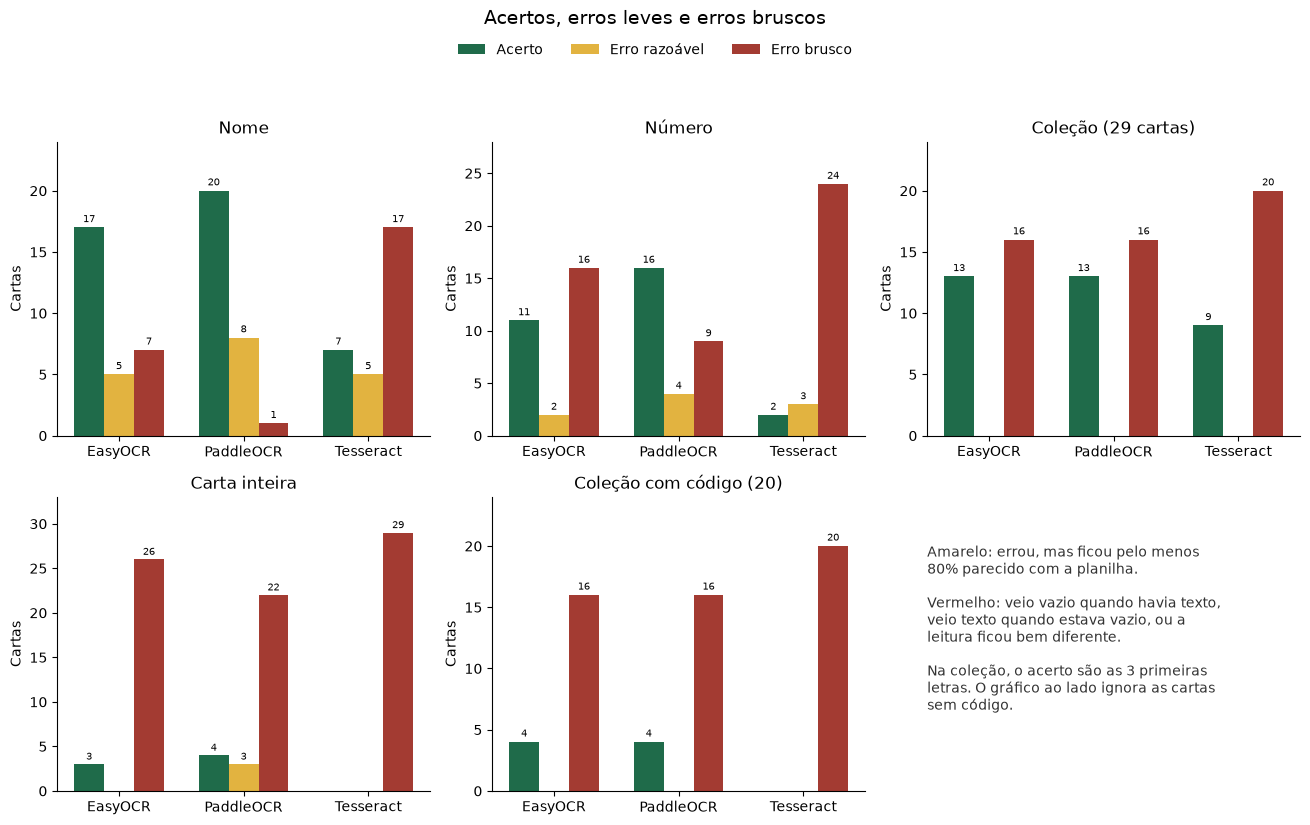

Figura: C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\OCR\runs\ocr-roi-v1_vs_planilha.png

Cartas em que PaddleOCR mais errou (25 de 29):
                   carta  bruscos  leves                                                     nome                       numero                 colecao
            Amoonguss ex        2      1                         Amoonguss ex -> Amoonguss (leve)    011/159 -> on/15 (brusco)   JTGpt -> Don (brusco)
                Larvitar        2      0                                                       ok  080/159 -> 0007152 (brusco)    JTGpt -> Mm (brusco)
        Mega Venusaur ex        2      0                                                       ok            013 -> — (brusco)   MEPpt -> MDn (brusco)
                  Mew ex        2      0                                   Mew ex -> Mew (brusco)                           ok   PAFpt -> PAO (brusco)
           Sigilyph do N        1      2                     Sigilyph do N -> Sigilyph doN (le

In [50]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
import sys
import unicodedata
from difflib import SequenceMatcher

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from read_card import _NUMBER_TRANSLATE

if "detail" not in globals():
    detail = pd.read_csv(ROOT / "runs" / f"{EXPERIMENT_NAME}_vs_planilha.csv", encoding="utf-8")

plot_df = detail.copy().fillna("")
ENGINES = ("easyocr", "paddleocr", "tesseract")
LABEL = {"easyocr": "EasyOCR", "paddleocr": "PaddleOCR", "tesseract": "Tesseract"}
KINDS = ("acerto", "razoavel", "brusco")
KIND_LABEL = {"acerto": "Acerto", "razoavel": "Erro razoável", "brusco": "Erro brusco"}
KIND_COLOR = {"acerto": "#1F6B4A", "razoavel": "#E2B340", "brusco": "#A33B32"}
SIMILAR = 0.80


def as_text(value) -> str:
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return ""
    return str(value).strip()


def fold_name(text: str) -> str:
    text = unicodedata.normalize("NFKD", as_text(text))
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = re.sub(r"[^0-9A-Za-z]+", " ", text).casefold()
    return re.sub(r"\s+", " ", text).strip()


def collection_code(text: str) -> str:
    return re.sub(r"[^A-Za-z0-9]+", "", as_text(text)).upper()


def fold_collection(text: str) -> str:
    return collection_code(text)[:3]


def fold_number(text: str) -> str:
    raw = as_text(text).upper().replace(" ", "").replace("\\", "/").replace("\u2044", "/")
    prefixed = re.search(r"([A-Z]{2,})(\d{1,4})/([A-Z]{2,})(\d{1,4})", raw)
    if prefixed:
        left, a, right, b = prefixed.groups()
        return f"{left}{int(a)}/{right}{int(b)}"
    translated = raw.translate(_NUMBER_TRANSLATE)
    plain = re.search(r"(\d{1,4})/(\d{1,4})", translated)
    if plain:
        return f"{int(plain.group(1))}/{int(plain.group(2))}"
    if "/" not in translated:
        digits = re.sub(r"\D", "", translated)
        letters = re.sub(r"[^A-Z]", "", translated)
        if digits and not letters:
            return str(int(digits))
    return re.sub(r"[^A-Z0-9/]", "", translated)


def edit_distance(left: str, right: str) -> int:
    if left == right:
        return 0
    if not left:
        return len(right)
    if not right:
        return len(left)
    prev = list(range(len(right) + 1))
    for i, ca in enumerate(left, start=1):
        curr = [i]
        for j, cb in enumerate(right, start=1):
            curr.append(min(prev[j] + 1, curr[j - 1] + 1, prev[j - 1] + (ca != cb)))
        prev = curr
    return prev[-1]


def same_collection(expected: str, predicted: str) -> bool:
    left = fold_collection(expected)
    right = fold_collection(predicted)
    if not left and not right:
        return True
    if not left or not right:
        return False
    return edit_distance(left, right) <= 1


def same_field(field: str, expected: str, predicted: str) -> bool:
    if field == "name":
        return fold_name(expected) == fold_name(predicted)
    if field == "number":
        return fold_number(expected) == fold_number(predicted)
    return same_collection(expected, predicted)


def similar_key(field: str, text: str) -> str:
    if field == "name":
        return fold_name(text)
    if field == "number":
        return fold_number(text)
    return collection_code(text)


def grade_field(field: str, expected: str, predicted: str) -> str:
    if same_field(field, expected, predicted):
        return "acerto"
    left = similar_key(field, expected)
    right = similar_key(field, predicted)
    if (not left) != (not right):
        return "brusco"
    if SequenceMatcher(None, left, right).ratio() >= SIMILAR:
        return "razoavel"
    return "brusco"


for engine in ENGINES:
    plot_df[f"grau_{engine}"] = [
        grade_field(field, expected, predicted)
        for field, expected, predicted in zip(plot_df["campo"], plot_df["certo"], plot_df[engine])
    ]


def card_kind(kinds) -> str:
    if all(kind == "acerto" for kind in kinds):
        return "acerto"
    if any(kind == "brusco" for kind in kinds):
        return "brusco"
    return "razoavel"


card_rows = []
for image, group in plot_df.groupby("imagem", sort=False):
    row = {"imagem": image}
    for engine in ENGINES:
        row[engine] = card_kind(group[f"grau_{engine}"].tolist())
    card_rows.append(row)
card_grade = pd.DataFrame(card_rows)


def bars_kinds(ax, by_engine, title):
    x = np.arange(len(ENGINES))
    width = 0.24
    totals = []
    for index, kind in enumerate(KINDS):
        offset = (index - 1) * width
        counts = [sum(item == kind for item in by_engine[engine]) for engine in ENGINES]
        totals.extend(counts)
        ax.bar(x + offset, counts, width, color=KIND_COLOR[kind], label=KIND_LABEL[kind])
        for xi, count in zip(x + offset, counts):
            if count:
                ax.text(xi, count + 0.25, str(count), ha="center", va="bottom", fontsize=7)
    ax.set_xticks(x)
    ax.set_xticklabels([LABEL[engine] for engine in ENGINES])
    ax.set_ylim(0, max(totals + [1]) + 4)
    ax.set_ylabel("Cartas")
    ax.set_title(title)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def kinds_for(frame):
    return {engine: frame[f"grau_{engine}"].tolist() for engine in ENGINES}


coded = plot_df[
    (plot_df["campo"] == "collection")
    & (plot_df["certo"].map(as_text) != "")
]

fig, axes = plt.subplots(2, 3, figsize=(13.2, 7.6))
field_titles = {
    "name": "Nome",
    "number": "Número",
    "collection": "Coleção (29 cartas)",
}
for ax, field in zip(axes[0], ("name", "number", "collection")):
    part = plot_df[plot_df["campo"] == field]
    bars_kinds(ax, kinds_for(part), field_titles[field])

bars_kinds(axes[1, 0], {engine: card_grade[engine].tolist() for engine in ENGINES}, "Carta inteira")
bars_kinds(axes[1, 1], kinds_for(coded), f"Coleção com código ({len(coded)})")

axes[1, 2].axis("off")
axes[1, 2].text(
    0.0,
    0.55,
    "Amarelo: errou, mas ficou pelo menos\n"
    "80% parecido com a planilha.\n\n"
    "Vermelho: veio vazio quando havia texto,\n"
    "veio texto quando estava vazio, ou a\n"
    "leitura ficou bem diferente.\n\n"
    "Na coleção, valem as 3 primeiras letras,\n"
    "maiúscula ou minúscula, e pode errar uma.\n"
    "O gráfico ao lado ignora as cartas sem código.",
    transform=axes[1, 2].transAxes,
    va="center",
    fontsize=10,
    color="#333333",
)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.0))
fig.suptitle("Acertos, erros leves e erros bruscos", y=1.08, fontsize=14)
fig.tight_layout()
chart_path = ROOT / "runs" / f"{EXPERIMENT_NAME}_vs_planilha.png"
fig.savefig(chart_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Figura: {chart_path}")


def model_rank(engine: str):
    hits = int((card_grade[engine] == "acerto").sum())
    brusque = int((plot_df[f"grau_{engine}"] == "brusco").sum())
    near = int((plot_df[f"grau_{engine}"] == "razoavel").sum())
    return (hits, -brusque, -near)


best = max(ENGINES, key=model_rank)


def field_note(row, engine: str) -> str:
    kind = row[f"grau_{engine}"]
    if kind == "acerto":
        return "ok"
    truth = as_text(row["certo"]) or "—"
    read = as_text(row[engine]) or "—"
    tag = "leve" if kind == "razoavel" else "brusco"
    return f"{truth} -> {read} ({tag})"


worse = []
for image, group in plot_df.groupby("imagem", sort=False):
    grades = group[f"grau_{best}"].tolist()
    brusque = sum(kind == "brusco" for kind in grades)
    near = sum(kind == "razoavel" for kind in grades)
    if brusque + near == 0:
        continue
    notes = {}
    for record in group.to_dict("records"):
        notes[record["campo"]] = field_note(record, best)
    card_name = as_text(group.loc[group["campo"] == "name", "certo"].iloc[0])
    worse.append({
        "carta": card_name,
        "bruscos": brusque,
        "leves": near,
        "nome": notes.get("name", ""),
        "numero": notes.get("number", ""),
        "colecao": notes.get("collection", ""),
    })

worse_df = pd.DataFrame(worse).sort_values(["bruscos", "leves", "carta"], ascending=[False, False, True])
print(f"\nCartas em que {LABEL[best]} mais errou ({len(worse_df)} de {plot_df['imagem'].nunique()}):")
print(worse_df.to_string(index=False))

